In [15]:
#Importing Data
import pandas as pd
import numpy as np

df = pd.read_csv("credit_card_transactions.csv")
print(df.shape)
#Convert Dates
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])


df["year"] = df["trans_date_trans_time"].dt.year
df["month"] = df["trans_date_trans_time"].dt.month
df["day"] = df["trans_date_trans_time"].dt.day
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.day_name()

#Covert DOB TO age

df["age"] = (df["trans_date_trans_time"].dt.year - df["dob"].dt.year)

#Create Age Group
bins = [0, 25, 35, 45, 55, 65, 100]

labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["age_group"] = pd.cut(df["age"], bins=bins,labels=labels)
df.head()


(1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,merch_zipcode,year,month,day,hour,day_of_week,age,age_group
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-82.048315,0,28705.0,2019,1,1,0,Tuesday,31,25-34
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.186462,0,NaN,2019,1,1,0,Tuesday,41,35-44
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.154481,0,83236.0,2019,1,1,0,Tuesday,57,55-64
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.561071,0,NaN,2019,1,1,0,Tuesday,52,45-54
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-78.632459,0,22844.0,2019,1,1,0,Tuesday,33,25-34


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


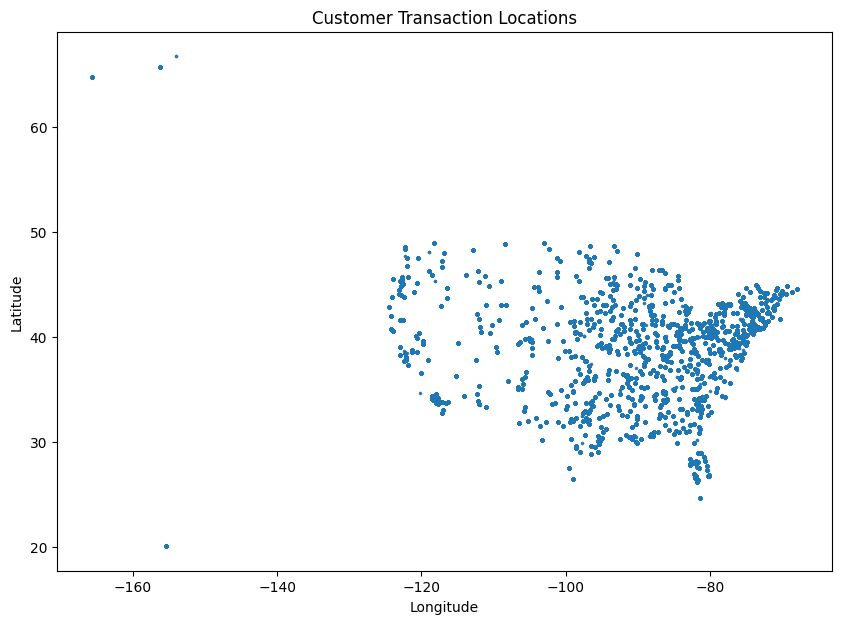

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,is_fraud,merch_zipcode,year,month,day,hour,day_of_week,age,age_group,customer_merchant_distance_km
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0,28705.0,2019,1,1,0,Tuesday,31,25-34,78.597568
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,0,NaN,2019,1,1,0,Tuesday,41,35-44,30.212176
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,0,83236.0,2019,1,1,0,Tuesday,57,55-64,108.206083
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,0,NaN,2019,1,1,0,Tuesday,52,45-54,95.673231
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,0,22844.0,2019,1,1,0,Tuesday,33,25-34,77.556744


In [17]:

#Calculate Customer distance from Merchant
import matplotlib.pyplot as plt
import numpy as np # Import numpy for vectorized math functions

plt.figure(figsize=(10,7))

plt.scatter(
    df["long"],
    df["lat"],
    s=2,
    alpha=0.2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Transaction Locations")

plt.show()



# from math import radians, sin, cos, sqrt, atan2 # Replace math functions with numpy

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    # Apply numpy.radians to the Series directly
    lat1, lon1, lat2, lon2 = np.radians(lat1), np.radians(lon1), np.radians(lat2), np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat/2)**2 + # Use np.sin
        np.cos(lat1) *    # Use np.cos
        np.cos(lat2) *    # Use np.cos
        np.sin(dlon/2)**2   # Use np.sin
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)) # Use np.arctan2 and np.sqrt

    return R * c

df["customer_merchant_distance_km"] = haversine(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

df.groupby("is_fraud")[
    "customer_merchant_distance_km"
].describe()





df.head()

In [18]:
#Category
category_analysis = (
    df.groupby("category")
      .agg(
          transactions=("trans_num", "count"),
          total_value=("amt", "sum"),
          avg_value=("amt", "mean"),
          fraud_count=("is_fraud", "sum")
      )
      .reset_index()
)

category_analysis["fraud_rate"] = (
    category_analysis["fraud_count"] /
    category_analysis["transactions"]
)


print(category_analysis)

          category  transactions  total_value   avg_value  fraud_count  \
0    entertainment         94014   6036678.56   64.210421          233   
1      food_dining         91461   4672459.44   51.086905          151   
2    gas_transport        131659   8351732.29   63.434572          618   
3      grocery_net         45452   2439412.68   53.670084          134   
4      grocery_pos        123638  14460822.38  116.960986         1743   
5   health_fitness         85879   4653108.02   54.182140          133   
6             home        123115   7173928.11   58.270139          198   
7        kids_pets        113035   6503680.16   57.536871          239   
8         misc_net         63287   5117709.26   80.865095          915   
9         misc_pos         79655   5009582.50   62.890999          250   
10   personal_care         90758   4353450.53   47.967678          220   
11    shopping_net         97543   8625149.68   88.424076         1713   
12    shopping_pos        116672   930

In [19]:
#Classify Transaction based on size
df["transaction_size"] = pd.cut(
    df["amt"],
    bins=[0, 25, 100, 500, 1000, np.inf],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)



df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_zipcode,year,month,day,hour,day_of_week,age,age_group,customer_merchant_distance_km,transaction_size
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,28705.0,2019,1,1,0,Tuesday,31,25-34,78.597568,Very Low
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,NaN,2019,1,1,0,Tuesday,41,35-44,30.212176,Medium
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,83236.0,2019,1,1,0,Tuesday,57,55-64,108.206083,Medium
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,NaN,2019,1,1,0,Tuesday,52,45-54,95.673231,Low
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,22844.0,2019,1,1,0,Tuesday,33,25-34,77.556744,Low


In [20]:
#MACHINE LEARNING
customer_df = (
    df.groupby("cc_num")
      .agg(
          transaction_count=("trans_num", "count"),
          total_spend=("amt", "sum"),
          avg_transaction=("amt", "mean"),
          max_transaction=("amt", "max"),
          fraud_count=("is_fraud", "sum"),
          categories_used=("category", "nunique")
      )
      .reset_index()
)
print(customer_df)


                  cc_num  transaction_count  total_spend  avg_transaction  \
0            60416207185               1518     85043.47        56.023366   
1            60422928733               1531    105640.20        69.000784   
2            60423098130                510     58673.63       115.046333   
3            60427851591                528     59129.61       111.987898   
4            60487002085                496     25160.11        50.726028   
..                   ...                ...          ...              ...   
978  4958589671582726883               1476     97973.69        66.377839   
979  4973530368125489546               1040     81508.22        78.373288   
980  4980323467523543940                532     39600.18        74.436429   
981  4989847570577635369               1007     88195.62        87.582542   
982  4992346398065154184               2059    139690.45        67.843832   

     max_transaction  fraud_count  categories_used  
0            3075.09  

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [22]:
#FRAUD DETECTION
df["is_fraud"].value_counts(normalize=True)
fraud_summary = (
    df.groupby("is_fraud")
      .agg(
          transactions=("trans_num", "count"),
          total_amount=("amt", "sum"),
          average_amount=("amt", "mean")
      )
)

fraud_summary

,transactions,total_amount,average_amount
is_fraud,,,
0,1289169,87234340.29,67.667110
1,7506,3988088.61,531.320092


In [23]:
#Calculating the Average possibility of fraud by category of transaction
df.groupby("category")["is_fraud"].mean()

,is_fraud
category,
entertainment,0.002478
food_dining,0.001651
gas_transport,0.004694
grocery_net,0.002948
grocery_pos,0.014098
health_fitness,0.001549
home,0.001608
kids_pets,0.002114
misc_net,0.014458


In [24]:
#Calculating the Average possibility of fraud by Time of Transaction
df.groupby("hour")["is_fraud"].mean()

,is_fraud
hour,
0,0.014940
1,0.015349
2,0.014652
3,0.014239
4,0.001099
5,0.001423
6,0.000946
7,0.001327
8,0.001153


In [25]:
#Calculating the Average possibility of fraud against State transaction was made
df.groupby("state")["is_fraud"].mean()

,is_fraud
state,
AK,0.016981
AL,0.005245
AR,0.005172
AZ,0.003435
CA,0.005784
CO,0.008141
CT,0.002077
DC,0.005812
DE,1.000000


In [26]:
#Calculating the Average possibility of fraud by Size of Transaction classification
df.groupby("transaction_size")["is_fraud"].mean()

/tmp/ipykernel_751/1317059997.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("transaction_size")["is_fraud"].mean()


,is_fraud
transaction_size,
Very Low,0.003348
Low,0.000167
Medium,0.010061
High,0.230782
Very High,0.241108


In [27]:
df.groupby("is_fraud")[
    "customer_merchant_distance_km"
].mean()

,customer_merchant_distance_km
is_fraud,
0,76.113756
1,76.268330


In [36]:
customer_df["avg_transaction"]

,avg_transaction
0,56.023366
1,69.000784
2,115.046333
3,111.987898
4,50.726028
...,...
978,66.377839
979,78.373288
980,74.436429
981,87.582542


In [37]:
#Save altered Database
df.to_csv("output.csv", index=False)
from google.colab import files
files.download("output.csv")